<a href="https://colab.research.google.com/github/Churdlez/BUS118s-ML_Basics/blob/main/customer_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

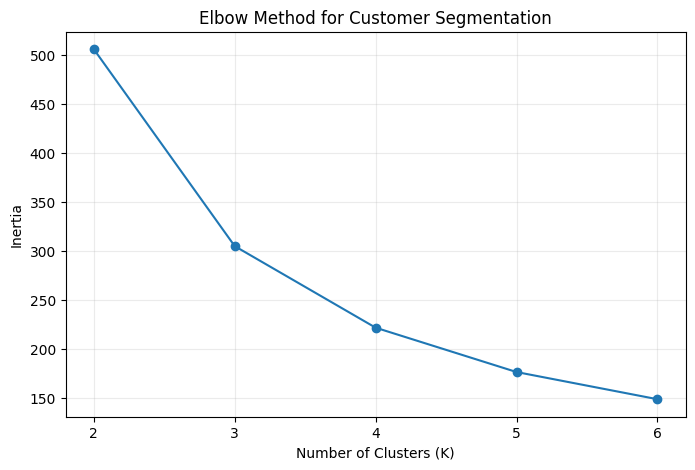

Silhouette Scores:
K = 2: 0.458
K = 3: 0.448
K = 4: 0.422
K = 5: 0.433
K = 6: 0.419

Number of records: 360
Selected number of clusters: 4

Cluster Characteristics:
         annual_spending  purchase_frequency    age
cluster                                            
0                 581.32                6.06  44.17
1                1289.05               13.41  35.90
2                 370.69                4.01  59.96
3                2428.54               24.10  41.78

Marketing Strategies:

Cluster 0:
Low-engagement customers: send re-engagement messages and introductory offers.

Cluster 1:
Regular customers: use cross-selling recommendations and tiered promotions.

Cluster 2:
Low-engagement customers: send re-engagement messages and introductory offers.

Cluster 3:
VIP customers: offer exclusive rewards, early access, and personalized service.

Customer segments were saved as customer_segments.csv


In [2]:
# Data source: Synthetic educational customer behavior dataset generated for this assignment.
# The dataset contains 360 realistic customer records.

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler


# Load the customer behavior dataset
DATA_FILE = "customer_behavior.csv"
df = pd.read_csv(DATA_FILE)

# Select numerical features for clustering
features = [
    "annual_spending",
    "purchase_frequency",
    "age"
]

X = df[features]

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Test different values of K
inertias = []
silhouette_scores = []
k_values = range(2, 7)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    cluster_labels = kmeans.fit_predict(X_scaled)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(X_scaled, cluster_labels)
    )

# Create the elbow plot
plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    inertias,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Customer Segmentation")
plt.xticks(list(k_values))
plt.grid(alpha=0.25)

plt.show()

# Display silhouette scores
print("Silhouette Scores:")

for k, score in zip(k_values, silhouette_scores):
    print(f"K = {k}: {score:.3f}")

# Select four clusters based on the elbow curve
optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=20
)

df["cluster"] = kmeans.fit_predict(X_scaled)

# Analyze the characteristics of each cluster
cluster_summary = (
    df.groupby("cluster")[features]
    .mean()
    .round(2)
)

print(f"\nNumber of records: {len(df)}")
print(f"Selected number of clusters: {optimal_k}")

print("\nCluster Characteristics:")
print(cluster_summary)

# Create marketing strategies for each cluster
def marketing_strategy(cluster_data):
    if cluster_data["annual_spending"] > 1800:
        return (
            "VIP customers: offer exclusive rewards, early access, "
            "and personalized service."
        )

    elif cluster_data["purchase_frequency"] > 15:
        return (
            "Frequent buyers: offer subscriptions, bundles, "
            "and loyalty points."
        )

    elif cluster_data["annual_spending"] < 700:
        return (
            "Low-engagement customers: send re-engagement messages "
            "and introductory offers."
        )

    else:
        return (
            "Regular customers: use cross-selling recommendations "
            "and tiered promotions."
        )

print("\nMarketing Strategies:")

for cluster_id, row in cluster_summary.iterrows():
    strategy = marketing_strategy(row)

    print(f"\nCluster {cluster_id}:")
    print(strategy)

# Save the customer cluster assignments
df.to_csv("customer_segments.csv", index=False)

print(
    "\nCustomer segments were saved as "
    "customer_segments.csv"
)